In [33]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [34]:
def print_multiple_accuracy(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("train_loss", "test_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        # train_acc = data["history"]["train_acc"]
        test_acc = data["history"]["test_acc"]


        print(label)
        # print("train_acc (finish):", train_acc[-1])
        print("test_acc (finish): ", test_acc[-1])
        print('\n')

In [35]:
def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что рисуем ("train_loss", "test_loss", )
    """

    plt.figure(figsize=(8, 5))

    markers = ["o", "s", "^", "D", "v", "x", "*"] 

    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        history = data["history"]
        values = history[metric]

        epochs = np.arange(1, len(values) + 1)

        plt.plot(
            epochs, 
            values, 
            label=label,
            marker=markers[i % len(markers)],
            markersize=5, 
            markevery=len(values)//5,
        )

    plt.xlabel("Rounds")
    plt.ylabel(metric)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#  CIFAR10

In [36]:
print_multiple_accuracy(
    run_dirs=[
        "saves_federated/fed_cifar10_adam_homo_cnn2_50_10_8",
        "saves_federated/fed_cifar10_adam_homo_cnn2_100_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_400_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_500_10_15",
        "saves_federated/fed_cifar10_adam_homo_resnet9_100_10_10",
        "saves_federated/fed_cifar10_adam_homo_resnet9_300_10_10",
    ],
    labels=[
        "adam_cnn2_50_10_8",
        "adam_cnn2_100_10_10",
        "adam_cnn2_400_10_10",
        "adam_cnn2_500_10_15",
        "adam_homo_resnet9_100_10_10",
        "adam_homo_resnet9_300_10_10",
    ],
    title="CIFAR10 Loss",
)

CIFAR10 Loss
adam_cnn2_50_10_8
test_acc (finish):  48.339999999999996


adam_cnn2_100_10_10
test_acc (finish):  56.15


adam_cnn2_400_10_10
test_acc (finish):  70.91


adam_cnn2_500_10_15
test_acc (finish):  73.52


adam_homo_resnet9_100_10_10
test_acc (finish):  42.11


adam_homo_resnet9_300_10_10
test_acc (finish):  64.07000000000001




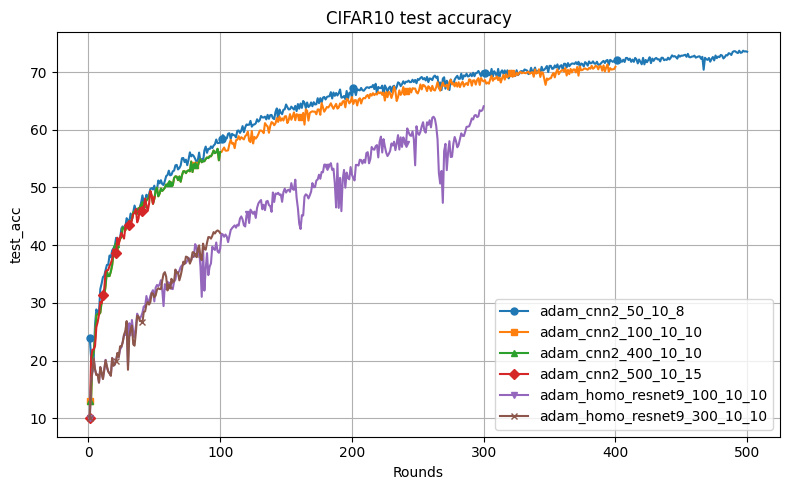

In [37]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/fed_cifar10_adam_homo_cnn2_500_10_15",
        "saves_federated/fed_cifar10_adam_homo_cnn2_400_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_100_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_50_10_8",
        "saves_federated/fed_cifar10_adam_homo_resnet9_300_10_10",
        "saves_federated/fed_cifar10_adam_homo_resnet9_100_10_10",
    ],
    labels=[
        "adam_cnn2_50_10_8",
        "adam_cnn2_100_10_10",
        "adam_cnn2_400_10_10",
        "adam_cnn2_500_10_15",
        "adam_homo_resnet9_100_10_10",
        "adam_homo_resnet9_300_10_10",
    ],
    metric="test_acc",
    title="CIFAR10 test accuracy",
)

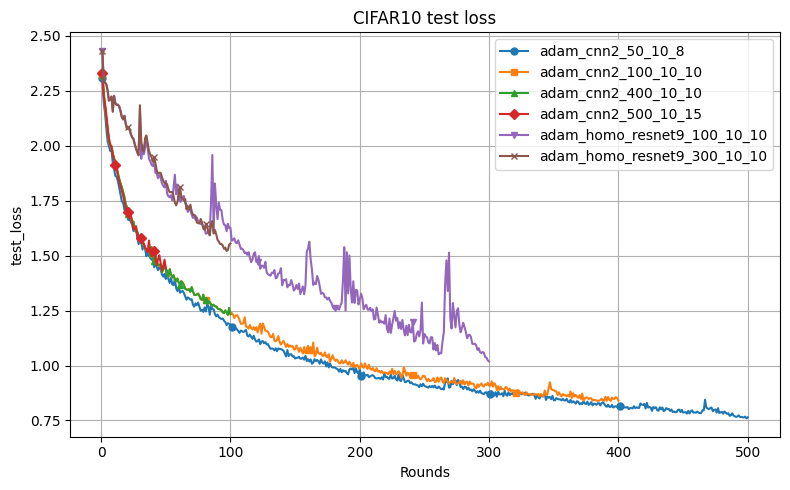

In [38]:
plot_multiple_histories(
    run_dirs=[
        "saves_federated/fed_cifar10_adam_homo_cnn2_500_10_15",
        "saves_federated/fed_cifar10_adam_homo_cnn2_400_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_100_10_10",
        "saves_federated/fed_cifar10_adam_homo_cnn2_50_10_8",
        "saves_federated/fed_cifar10_adam_homo_resnet9_300_10_10",
        "saves_federated/fed_cifar10_adam_homo_resnet9_100_10_10",
    ],
    labels=[
        "adam_cnn2_50_10_8",
        "adam_cnn2_100_10_10",
        "adam_cnn2_400_10_10",
        "adam_cnn2_500_10_15",
        "adam_homo_resnet9_100_10_10",
        "adam_homo_resnet9_300_10_10",
    ],
    metric="test_loss",
    title="CIFAR10 test loss",
)